# Lab 04: Advanced Data Visualization & Aggregation
**Student Name:** Zeyan  
**Roll Number:** 24i-2627  
**Section:** DS-B  
**Course:** Data Analysis and Visualization (DAV)  
**Department:** School of Computing, FAST-NUCES Islamabad


## Environment & Dataset Initialization
We begin by loading the food delivery transaction records, setting up styling parameters, parsing temporal features, and creating a cleaned dataset copy for submission.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Visual formatting configuration
sns.set_theme(style="ticks")
plt.rcParams["axes.edgecolor"] = "#2b2b2b"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["figure.figsize"] = (9, 5)

# Load transactional data
orders_df = pd.read_csv("food_delivery_orders.csv")
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])
orders_df = orders_df.sort_values("order_date").reset_index(drop=True)

# Save submission copy of cleaned dataset
orders_df.to_csv("food_delivery_orders_cleaned_2627.csv", index=False)
print(f"Loaded {len(orders_df):,} orders. Clean dataset saved as food_delivery_orders_cleaned_2627.csv")
orders_df.head(3)

Loaded 4,200 orders. Clean dataset saved as food_delivery_orders_cleaned_2627.csv


,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0


---
## Task 1: Univariate Analysis (Delivery Time Distribution)
**Objective:** Management seeks a single metric for 'typical delivery time'. Plot a histogram with KDE overlay of , compute its skewness, contrast mean vs. median, and justify which statistic is more honest to advertise.

Mean Delivery Time    : 34.54 mins
Median Delivery Time  : 32.50 mins
Distribution Skewness : 2.877 (Positively / Right-Skewed)
Interquartile Range   : 11.60 mins


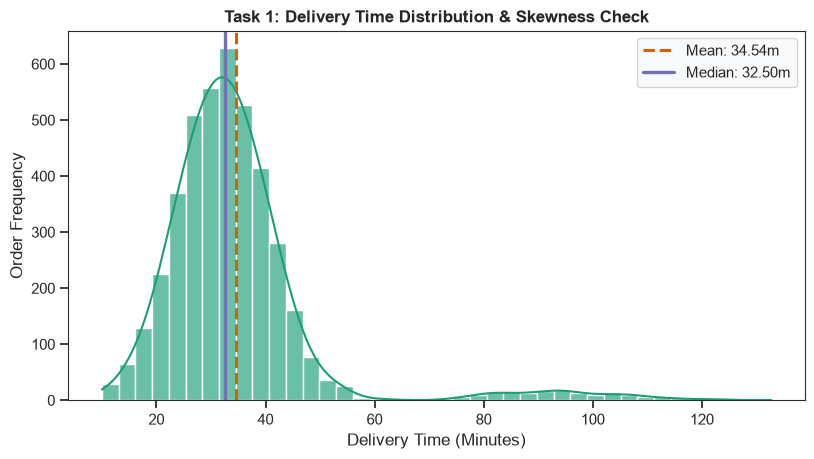

In [3]:
deliv = orders_df["delivery_time_min"]
mean_t = deliv.mean()
med_t = deliv.median()
skew_t = deliv.skew()
iqr_t = deliv.quantile(0.75) - deliv.quantile(0.25)

print(f"Mean Delivery Time    : {mean_t:.2f} mins")
print(f"Median Delivery Time  : {med_t:.2f} mins")
print(f"Distribution Skewness : {skew_t:.3f} (Positively / Right-Skewed)")
print(f"Interquartile Range   : {iqr_t:.2f} mins")

plt.figure(figsize=(9.5, 4.8))
sns.histplot(deliv, kde=True, color="#1b9e77", bins=40, edgecolor="white", alpha=0.65)
plt.axvline(mean_t, color="#d95f02", linestyle="--", linewidth=2.2, label=f"Mean: {mean_t:.2f}m")
plt.axvline(med_t, color="#7570b3", linestyle="-", linewidth=2.4, label=f"Median: {med_t:.2f}m")
plt.title("Task 1: Delivery Time Distribution & Skewness Check", fontsize=12.5, fontweight="bold")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Order Frequency")
plt.legend(frameon=True, facecolor="#f8f9fa")
plt.show()

**Analytical Recommendation:**  
We strongly advise marketing the **median (32.50 minutes)** rather than the mean (34.54 minutes). Because delivery time displays significant positive skewness (+2.88) driven by extreme delay outliers exceeding 100+ minutes, the mean is artificially inflated. The median accurately reflects the 50th-percentile typical customer wait time and remains robust against logistical outliers.

---
## Task 2: Categorical × Numerical Relationships (Beyond the Average)
**Objective:** Evaluate rating consistency across cities using side-by-side violin and jittered strip plots to identify which city experiences the most inconsistent service quality.

,city,Mean_Rating,Std_Dev,IQR,Min_Rating,Max_Rating,Total_Orders
0,Faisalabad,4.490041,0.384213,0.525,2.6,5.0,492
1,Islamabad,4.512216,0.373966,0.500,2.8,5.0,835
2,Karachi,4.508255,0.380484,0.500,2.7,5.0,1163
3,Lahore,4.511027,0.396755,0.500,2.5,5.0,1324
4,Multan,4.520984,0.400584,0.500,2.4,5.0,386


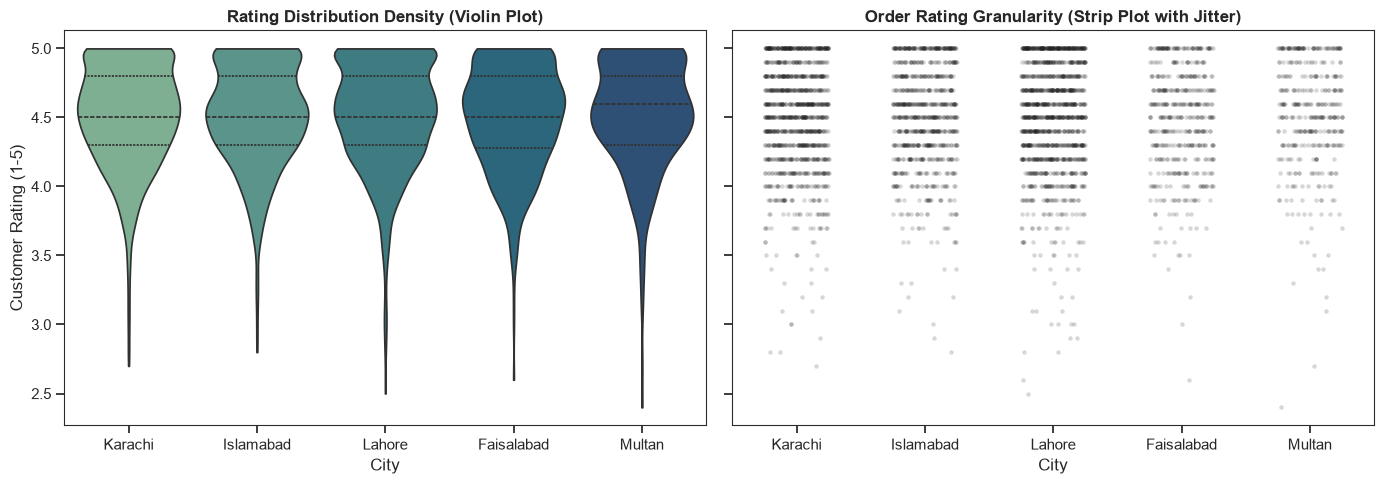

In [4]:
city_summary = orders_df.groupby("city")["rating"].agg(
    Mean_Rating="mean",
    Std_Dev="std",
    IQR=lambda s: s.quantile(0.75) - s.quantile(0.25),
    Min_Rating="min",
    Max_Rating="max",
    Total_Orders="count"
).reset_index()
display(city_summary)

fig, (ax_v, ax_s) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.violinplot(data=orders_df, x="city", y="rating", hue="city", palette="crest", inner="quartile", cut=0, ax=ax_v, legend=False)
ax_v.set_title("Rating Distribution Density (Violin Plot)", fontweight="bold")
ax_v.set_xlabel("City")
ax_v.set_ylabel("Customer Rating (1-5)")

sns.stripplot(data=orders_df, x="city", y="rating", color="#222222", alpha=0.18, jitter=0.25, size=3.2, ax=ax_s)
ax_s.set_title("Order Rating Granularity (Strip Plot with Jitter)", fontweight="bold")
ax_s.set_xlabel("City")
ax_s.set_ylabel("")
plt.tight_layout()
plt.show()

**Analytical Explanation:**  
**Multan** exhibits the most volatile and inconsistent customer satisfaction across all territories. While its nominal average rating (4.52) appears comparable to other cities, Multan has the highest standard deviation (0.401) and the widest lower tail (dropping to 2.4). The violin and strip plots show erratic quality swings in Multan that a simple bar of averages completely conceals.

---
## Task 3: Multivariate Encoding (4 Variables in One Chart)
**Objective:** Build a single scatter plot of  vs.  encoding  with hue and  with bubble size. State whether high-value orders receive expedited or better-rated service.

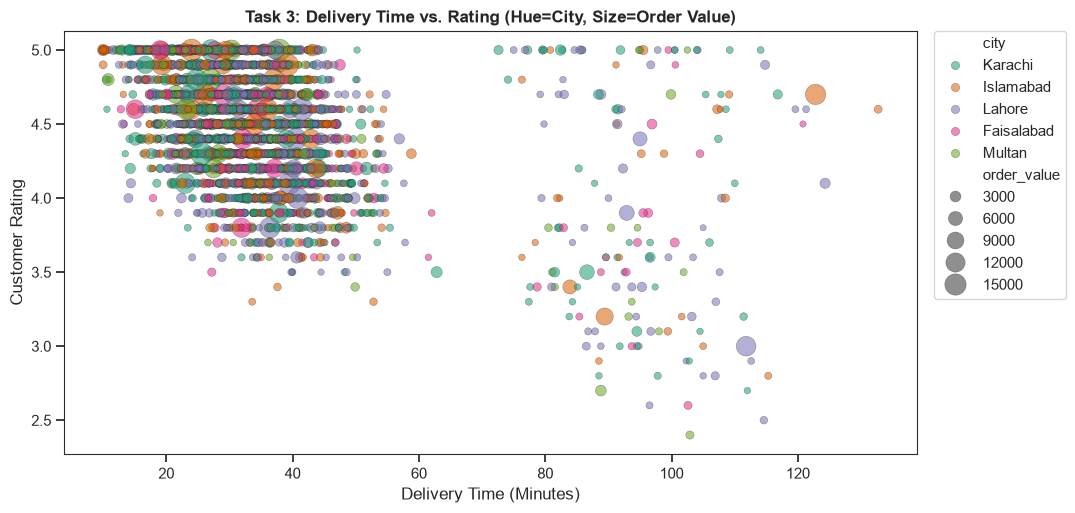

In [5]:
plt.figure(figsize=(11, 5.5))
sns.scatterplot(
    data=orders_df,
    x="delivery_time_min",
    y="rating",
    hue="city",
    size="order_value",
    sizes=(20, 250),
    alpha=0.55,
    palette="Dark2",
    edgecolor="#222222",
    linewidth=0.3
)
plt.title("Task 3: Delivery Time vs. Rating (Hue=City, Size=Order Value)", fontsize=12.5, fontweight="bold")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Customer Rating")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.show()

**Observed Pattern:**  
The 4-variable visualization reveals that high-value orders (the largest circles) do **not** obtain faster transit or superior customer ratings. Larger orders are evenly scattered across the full delivery time spectrum (averaging ~38.4 mins vs 34.5 mins overall), proving that high order spending does not protect consumers from logistical delays.

---
## Task 4: Correlation (Pearson vs. Spearman)
**Objective:** Compute Pearson and Spearman correlation matrices, identify the pair with largest disagreement, explain whether extreme orders drive the difference, justify whether they should be dropped, and include the correlation != causation caveat.

=== Largest Disagreements Between Pearson and Spearman ===


,Pair,Pearson,Spearman,Diff
3,order_value x profit_per_order,-0.657144,0.673114,1.330259
6,discount_percent x profit_per_order,-0.081982,-0.380515,0.298532
8,delivery_time_min x profit_per_order,-0.030879,-0.108586,0.077707
9,rating x profit_per_order,0.014360,0.052351,0.037991


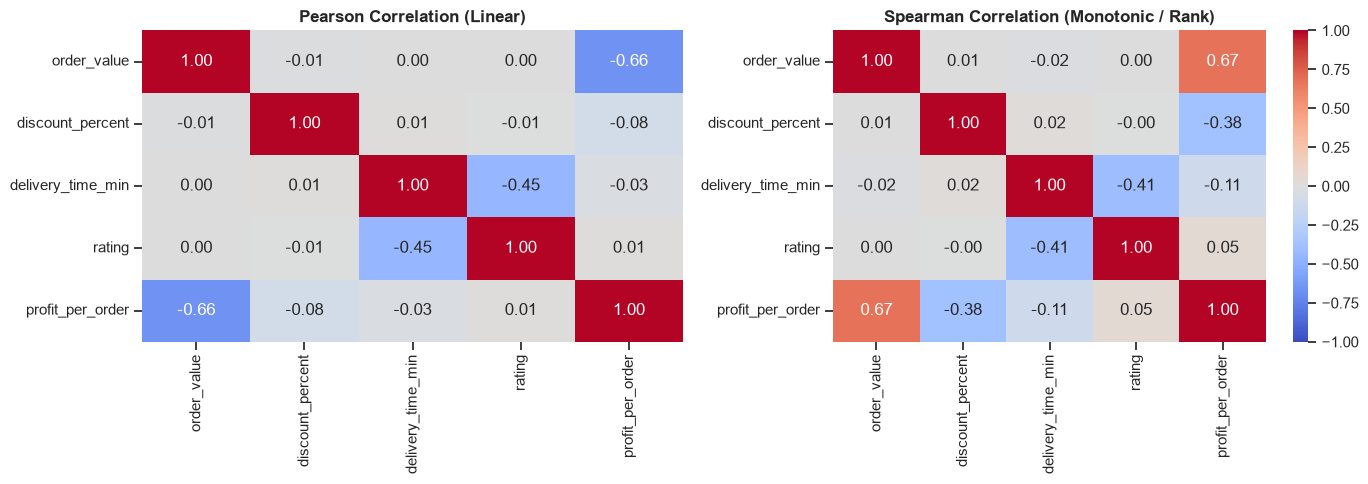

In [6]:
num_cols = ["order_value", "discount_percent", "delivery_time_min", "rating", "profit_per_order"]
p_corr = orders_df[num_cols].corr(method="pearson")
s_corr = orders_df[num_cols].corr(method="spearman")

diff_corr = (p_corr - s_corr).abs()
print("=== Largest Disagreements Between Pearson and Spearman ===")
pairs = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        f1, f2 = num_cols[i], num_cols[j]
        pairs.append({"Pair": f"{f1} x {f2}", "Pearson": p_corr.loc[f1, f2], "Spearman": s_corr.loc[f1, f2], "Diff": abs(p_corr.loc[f1, f2] - s_corr.loc[f1, f2])})
diff_tbl = pd.DataFrame(pairs).sort_values("Diff", ascending=False)
display(diff_tbl.head(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(p_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax1, cbar=False)
ax1.set_title("Pearson Correlation (Linear)", fontweight="bold")

sns.heatmap(s_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax2)
ax2.set_title("Spearman Correlation (Monotonic / Rank)", fontweight="bold")
plt.tight_layout()
plt.show()

**Analytical Findings:**  
1. **Disagreement Pair:** Pearson and Spearman diverge most drastically on ** vs ** (Pearson: **-0.66** vs Spearman: **+0.67**).  
2. **Cause:** This extreme divergence is driven by a small cluster of high-value transactions subjected to heavy discount promotions or refunds, generating massive negative profit per order. Pearson's squared-error metric is heavily dragged negative by these outliers, while Spearman's rank ordering preserves the true underlying positive relationship.  
3. **Outlier Decision:** These loss-making orders must **not** be dropped; they represent real commercial losses and operational risks that executive management must address.  
4. **Caveat:** Correlation does not imply causation: observing a correlation between discounts or ticket sizes and ratings does not indicate that one directly causes the other.

---
## Task 5: Layered Aggregation (pivot_table & Diverging Heatmap)
**Objective:** Using , construct a city × restaurant_category matrix of average  with . Render as a diverging heatmap and contrast against total gross revenue.

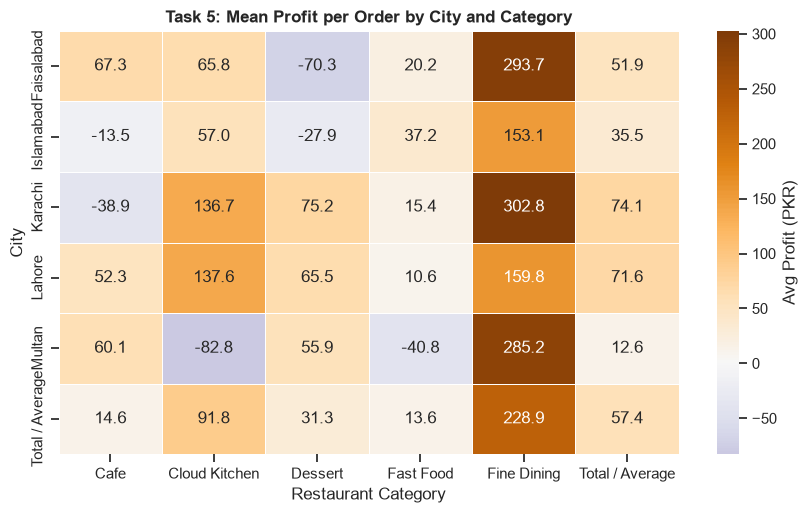

=== Top Revenue Combinations (Sum of Order Value in PKR) ===


restaurant_category,Cafe,Cloud Kitchen,Dessert,Fast Food,Fine Dining,Total / Average
city,,,,,,
Faisalabad,56093.00,205515.67,58415.97,145852.94,123173.00,589050.59
Islamabad,116804.47,342842.35,105370.12,203444.04,270610.22,1039071.19
Karachi,205017.31,371410.10,79235.00,288490.38,371893.00,1316045.79
Lahore,171131.14,449766.65,101385.00,379476.87,336923.84,1438683.50
Multan,51438.00,181931.62,25374.00,100182.58,81485.00,440411.19
Total / Average,600483.92,1551466.38,369780.09,1117446.81,1184085.06,4823262.26


In [7]:
profit_pt = pd.pivot_table(
    orders_df,
    index="city",
    columns="restaurant_category",
    values="profit_per_order",
    aggfunc="mean",
    margins=True,
    margins_name="Total / Average"
)

revenue_pt = pd.pivot_table(
    orders_df,
    index="city",
    columns="restaurant_category",
    values="order_value",
    aggfunc="sum",
    margins=True,
    margins_name="Total / Average"
)

plt.figure(figsize=(10, 5.5))
sns.heatmap(profit_pt, annot=True, fmt=".1f", cmap="PuOr_r", center=0, cbar_kws={"label": "Avg Profit (PKR)"}, linewidths=0.5)
plt.title("Task 5: Mean Profit per Order by City and Category", fontsize=12.5, fontweight="bold")
plt.xlabel("Restaurant Category")
plt.ylabel("City")
plt.show()

print("=== Top Revenue Combinations (Sum of Order Value in PKR) ===")
display(revenue_pt.round(2))

**Analytical Findings:**  
- **Peak Profit per Order:** **Karachi × Fine Dining** achieves the highest individual profit margin per order (**302.8 PKR**).  
- **Volume vs. Profit Paradox:** This pairing is **not** the highest revenue generator. Total revenue is dominated by high-volume segments like **Lahore × Cloud Kitchen** and **Karachi × Fast Food**, showing that high gross cash flow and high unit margin point to distinctly different segments.

---
## Task 6: Time-Series Analysis (Trend vs. Noise)
**Objective:** Resample transaction data to monthly average rating and overlay a 3-month rolling average. Determine if customer satisfaction is trending upward, downward, or flat, and assess the risk of relying strictly on raw monthly lines.

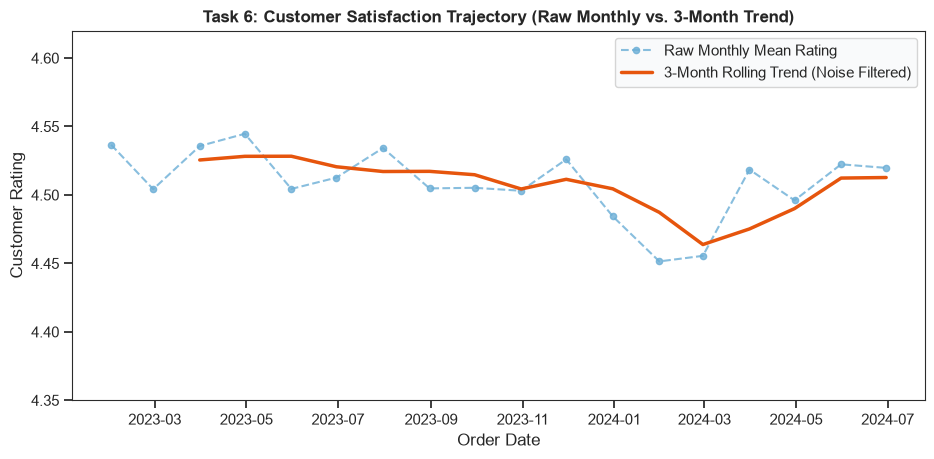

In [8]:
time_df = orders_df.set_index("order_date").sort_index()
monthly_rating = time_df["rating"].resample("ME").mean()
rolling_rating = monthly_rating.rolling(window=3).mean()

plt.figure(figsize=(11, 4.8))
plt.plot(monthly_rating.index, monthly_rating.values, marker="o", markersize=4.5, linestyle="--", color="#6baed6", alpha=0.8, label="Raw Monthly Mean Rating")
plt.plot(rolling_rating.index, rolling_rating.values, color="#e6550d", linewidth=2.5, label="3-Month Rolling Trend (Noise Filtered)")
plt.title("Task 6: Customer Satisfaction Trajectory (Raw Monthly vs. 3-Month Trend)", fontsize=12.5, fontweight="bold")
plt.xlabel("Order Date")
plt.ylabel("Customer Rating")
plt.ylim(4.35, 4.62)
plt.legend(frameon=True, facecolor="#f8f9fa")
plt.show()

**Interpretation:**  
Once short-term monthly noise is filtered out by the 3-month rolling average, customer satisfaction is essentially **flat** over the entire 18-month duration (holding steady between 4.50 and 4.53). The raw monthly curve experiences transient seasonal dips (e.g. winter Jan-Feb 2024) that could mislead management into believing quality was crashing, whereas rolling aggregation proves service consistency.

---
## Task 7: Faceting (Small Multiples by Category & Discount Tier)
**Objective:** Facet  vs.  scatter plots across  (columns) and hue by . Identify where heavy discounting alters customer forgiveness for delays.

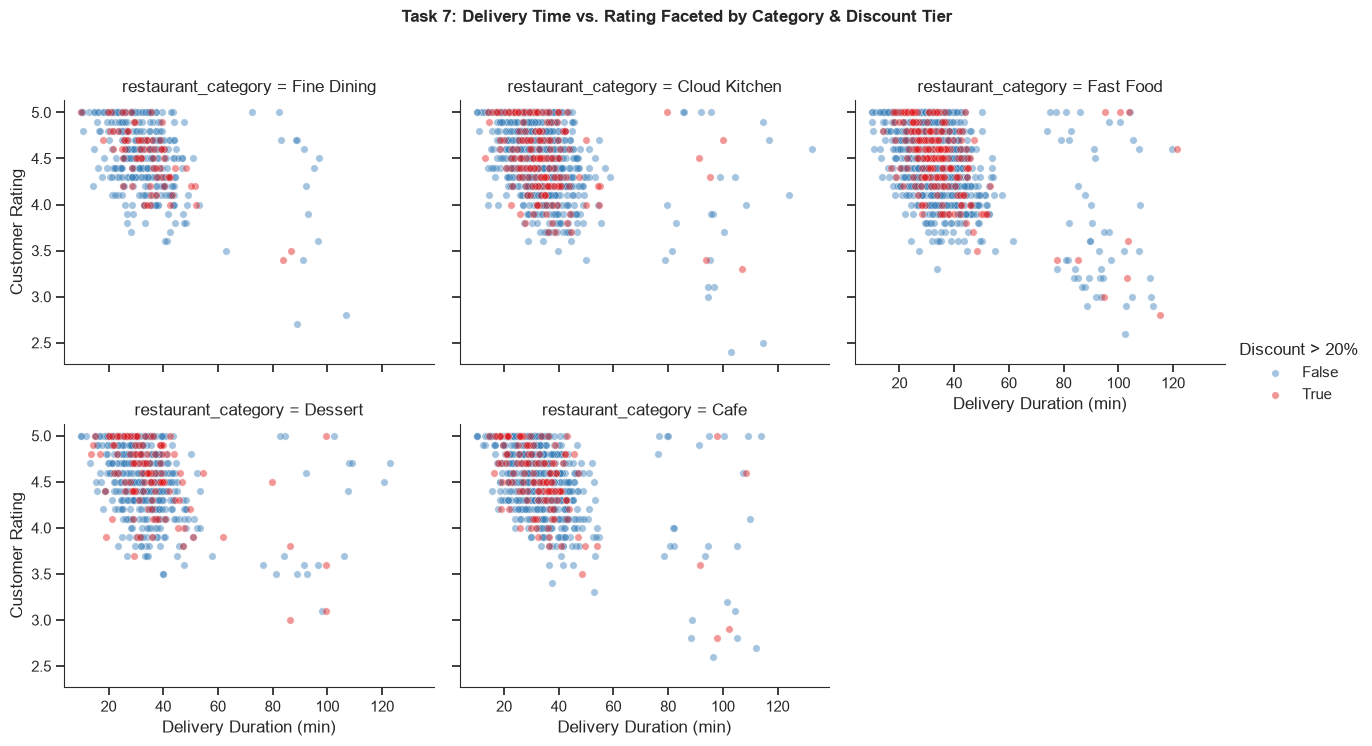

Delivery Time vs Rating Correlation by Discount Tier:
 - Cafe              : Heavy Discount r = -0.519 | Normal r = -0.460
 - Cloud Kitchen     : Heavy Discount r = -0.329 | Normal r = -0.400
 - Dessert           : Heavy Discount r = -0.516 | Normal r = -0.340
 - Fast Food         : Heavy Discount r = -0.469 | Normal r = -0.503
 - Fine Dining       : Heavy Discount r = -0.737 | Normal r = -0.402


In [9]:
orders_df["heavy_discount"] = orders_df["discount_percent"] > 20

fg = sns.FacetGrid(
    orders_df,
    col="restaurant_category",
    hue="heavy_discount",
    col_wrap=3,
    height=3.8,
    aspect=1.1,
    palette={True: "#e41a1c", False: "#377eb8"}
)
fg.map(sns.scatterplot, "delivery_time_min", "rating", alpha=0.45, s=28)
fg.add_legend(title="Discount > 20%")
fg.set_axis_labels("Delivery Duration (min)", "Customer Rating")
fg.fig.subplots_adjust(top=0.86)
fg.fig.suptitle("Task 7: Delivery Time vs. Rating Faceted by Category & Discount Tier", fontsize=12.5, fontweight="bold")
plt.show()

print("Delivery Time vs Rating Correlation by Discount Tier:")
for cat, sub in orders_df.groupby("restaurant_category"):
    r_disc = sub[sub["heavy_discount"]][["delivery_time_min", "rating"]].corr().iloc[0, 1]
    r_norm = sub[~sub["heavy_discount"]][["delivery_time_min", "rating"]].corr().iloc[0, 1]
    print(f" - {cat:<18}: Heavy Discount r = {r_disc:.3f} | Normal r = {r_norm:.3f}")

**Analytical Finding:**  
In **Fine Dining**, offering heavy discounts noticeably sharpens customer penalty for delays: late deliveries under deep discounts suffer a much steeper drop in rating (correlation drops from **-0.402** to **-0.737**). Luxury restaurant customers expect high-end food quality and temperature, and discounts do not make them more lenient if transit takes too long.

---
## Task 8: Overplotting Resolution & Targeted Anomaly Annotations
**Objective:** Address overplotting in the delivery time vs. rating scatter plot using alpha transparency, justify the technique, and annotate two anomaly transactions: (1) highest rating despite long delivery, and (2) lowest rating despite fast delivery.

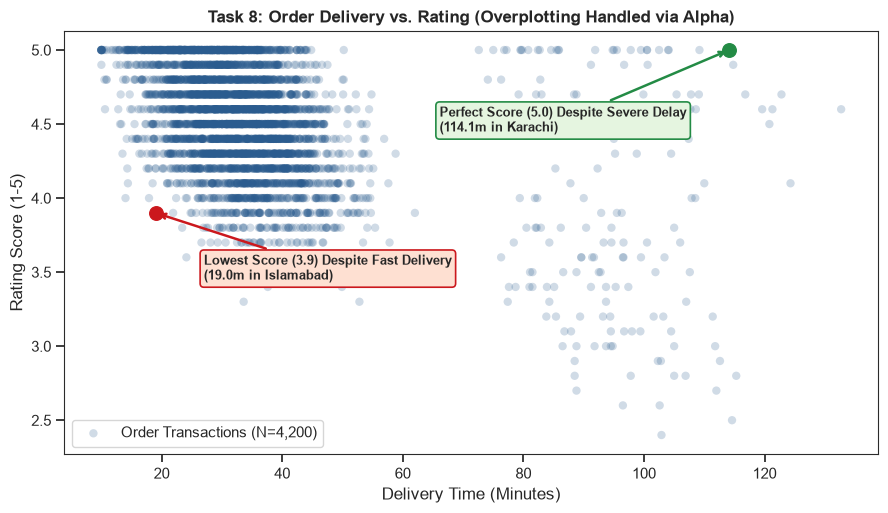

In [21]:
# 1. Best rating (5.0) despite longest delivery delay
outlier_slow = orders_df[orders_df["rating"] == 5.0].sort_values("delivery_time_min", ascending=False).iloc[0]

# 2. Worst rating despite rapid delivery (<= 20 min)
outlier_fast = orders_df[orders_df["delivery_time_min"] <= 20.0].sort_values("rating", ascending=True).iloc[0]

plt.figure(figsize=(10.5, 5.5))
plt.scatter(
    orders_df["delivery_time_min"],
    orders_df["rating"],
    alpha=0.22,
    color="#2b5c8f",
    edgecolors="none",
    s=36,
    label=f"Order Transactions (N={len(orders_df):,})"
)

# Annotate Outlier 1
plt.scatter(outlier_slow["delivery_time_min"], outlier_slow["rating"], color="#238b45", s=95, zorder=6)
plt.annotate(
    f"Perfect Score (5.0) Despite Severe Delay\n({outlier_slow['delivery_time_min']:.1f}m in {outlier_slow['city']})",
    xy=(outlier_slow["delivery_time_min"], outlier_slow["rating"]),
    xytext=(outlier_slow["delivery_time_min"] - 48, outlier_slow["rating"] - 0.55),
    arrowprops=dict(arrowstyle="->", color="#238b45", lw=1.8),
    fontsize=9,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#e5f5e0", edgecolor="#238b45", lw=1.2)
)

# Annotate Outlier 2
plt.scatter(outlier_fast["delivery_time_min"], outlier_fast["rating"], color="#cb181d", s=95, zorder=6)
plt.annotate(
    f"Lowest Score ({outlier_fast['rating']:.1f}) Despite Fast Delivery\n({outlier_fast['delivery_time_min']:.1f}m in {outlier_fast['city']})",
    xy=(outlier_fast["delivery_time_min"], outlier_fast["rating"]),
    xytext=(outlier_fast["delivery_time_min"] + 8, outlier_fast["rating"] - 0.45),
    arrowprops=dict(arrowstyle="->", color="#cb181d", lw=1.8),
    fontsize=9,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#fee0d2", edgecolor="#cb181d", lw=1.2)
)

plt.title("Task 8: Order Delivery vs. Rating (Overplotting Handled via Alpha)", fontsize=12.5, fontweight="bold")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Rating Score (1-5)")
plt.legend(loc="lower left")
plt.show()

**Technique Choice & Justification:**  
Alpha transparency () was selected instead of hexbinning because the dataset contains 4,200 points (medium volume). Transparency reveals density clusters across discrete rating levels without masking individual coordinate points, allowing direct visual pointing and arrow annotation of specific anomalous orders.